### <font color='gold'> Import les librairies requises

In [1]:
# Importer  packages
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
 # Supprimer les warnings
 import warnings
 warnings.filterwarnings('ignore')

###<font color='gold'> Importer et lire les données

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Importer data
df = pd.read_csv('/content/drive/MyDrive/ML-AI-HUB/Unsupervised Learning /Clustering/Doc 2/Customer_dataset.csv')

#### Description des variables du jeu de données "Télécommunications"

Ce jeu de données contient des informations sur le comportement et les caractéristiques des clients d'une entreprise de télécommunications. L'objectif est d'effectuer une segmentation (clustering) des clients pour identifier des groupes homogènes.

| Variable | Type | Description |
|----------|------|-------------|
| `Call Failure` | Numérique | Nombre d'appels échoués du client. |
| `Complains` | Numérique | Nombre de plaintes/réclamations émises par le client. |
| `Subscription Length` | Numérique | Durée de l'abonnement du client (probablement en mois). |
| `Charge Amount` | Numérique | Montant total facturé au client. |
| `Seconds of Use` | Numérique | Temps total d'utilisation des services (en secondes). |
| `Frequency of use` | Numérique | Fréquence d'utilisation des services de télécommunication. |
| `Frequency of SMS` | Numérique | Fréquence d'envoi de SMS par le client. |
| `Distinct Called Numbers` | Numérique | Nombre de numéros de téléphone différents contactés par le client. |
| `Age Group` | Numérique | Catégorie d'âge du client (codée numériquement). |
| `Status` | Numérique | Statut du client (probablement actif/inactif ou autre classification). |
| `Age` | Numérique | Âge exact du client (en années). |
| `Customer Value` | Numérique | Valeur économique ou score de valeur du client pour l'entreprise. |

In [5]:
# Afficher les données
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Status,Age,Customer Value
0,8,0,38,0,4370,71,5,17,3,1,30,197.640
1,0,0,39,0,318,5,7,4,2,2,25,46.035
2,10,0,37,0,2453,60,359,24,3,1,30,1536.520
3,10,0,38,0,4198,66,1,35,1,1,15,240.020
4,3,0,38,0,2393,58,2,33,1,1,15,145.805


In [6]:
# Dimension des données
df.shape

(3150, 12)

In [7]:
# Infos des données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Status                   3150 non-null   int64  
 10  Age                      3150 non-null   int64  
 11  Customer Value           3150 non-null   float64
dtypes: float64(1), int64(11)
memory usage: 295.4 KB


In [8]:
# décrire les données
df.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Status,Age,Customer Value
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.248254,30.998413,470.972916
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.432069,8.831095,517.015433
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,15.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,25.000000,113.801250
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,30.000000,228.480000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,30.000000,788.388750
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,55.000000,2165.280000


### <font color='gold'> Preparation des données

In [9]:
# renommer les index
df.index = ['Client' + str(i +1) for i in range(len(df))]
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Status,Age,Customer Value
Client1,8,0,38,0,4370,71,5,17,3,1,30,197.640
Client2,0,0,39,0,318,5,7,4,2,2,25,46.035
Client3,10,0,37,0,2453,60,359,24,3,1,30,1536.520
Client4,10,0,38,0,4198,66,1,35,1,1,15,240.020
Client5,3,0,38,0,2393,58,2,33,1,1,15,145.805


In [10]:
# Données en format matriciel
x = df.values
x[:5]

array([[8.00000e+00, 0.00000e+00, 3.80000e+01, 0.00000e+00, 4.37000e+03,
        7.10000e+01, 5.00000e+00, 1.70000e+01, 3.00000e+00, 1.00000e+00,
        3.00000e+01, 1.97640e+02],
       [0.00000e+00, 0.00000e+00, 3.90000e+01, 0.00000e+00, 3.18000e+02,
        5.00000e+00, 7.00000e+00, 4.00000e+00, 2.00000e+00, 2.00000e+00,
        2.50000e+01, 4.60350e+01],
       [1.00000e+01, 0.00000e+00, 3.70000e+01, 0.00000e+00, 2.45300e+03,
        6.00000e+01, 3.59000e+02, 2.40000e+01, 3.00000e+00, 1.00000e+00,
        3.00000e+01, 1.53652e+03],
       [1.00000e+01, 0.00000e+00, 3.80000e+01, 0.00000e+00, 4.19800e+03,
        6.60000e+01, 1.00000e+00, 3.50000e+01, 1.00000e+00, 1.00000e+00,
        1.50000e+01, 2.40020e+02],
       [3.00000e+00, 0.00000e+00, 3.80000e+01, 0.00000e+00, 2.39300e+03,
        5.80000e+01, 2.00000e+00, 3.30000e+01, 1.00000e+00, 1.00000e+00,
        1.50000e+01, 1.45805e+02]])

In [11]:
# Importer normalize
from sklearn.preprocessing import normalize
# Normaliser x
x = normalize(x)
x[:5]

array([[1.82842291e-03, 0.00000000e+00, 8.68500883e-03, 0.00000000e+00,
        9.98776016e-01, 1.62272533e-02, 1.14276432e-03, 3.88539869e-03,
        6.85658592e-04, 2.28552864e-04, 6.85658592e-03, 4.51711881e-02],
       [0.00000000e+00, 0.00000000e+00, 1.20078342e-01, 0.00000000e+00,
        9.79100323e-01, 1.53946592e-02, 2.15525228e-02, 1.23157273e-02,
        6.15786367e-03, 6.15786367e-03, 7.69732958e-02, 1.41738627e-01],
       [3.42724335e-03, 0.00000000e+00, 1.26808004e-02, 0.00000000e+00,
        8.40702794e-01, 2.05634601e-02, 1.23038036e-01, 8.22538404e-03,
        1.02817301e-03, 3.42724335e-04, 1.02817301e-02, 5.26602795e-01],
       [2.37770839e-03, 0.00000000e+00, 9.03529188e-03, 0.00000000e+00,
        9.98161981e-01, 1.56928754e-02, 2.37770839e-04, 8.32197936e-03,
        2.37770839e-04, 2.37770839e-04, 3.56656258e-03, 5.70697567e-02],
       [1.25066839e-03, 0.00000000e+00, 1.58417995e-02, 0.00000000e+00,
        9.97616482e-01, 2.41795888e-02, 8.33778924e-04, 1.37

In [12]:
# Importer PCA
from sklearn.decomposition import PCA
#Instantier le modèle PCA avec n_components = 2
pca_model= PCA(n_components = 2)
# Matrice des 2 composantes
feature_pca = pca_model.fit_transform(x)
# Convertir la matrice features_pca en dataframe
New_df = pd.DataFrame(feature_pca, columns = ['PCA1', 'PCA2'])
New_df.head()

,PCA1,PCA2
0,0.092026,-0.081771
1,-0.010775,-0.002793
2,-0.022317,0.426592
3,0.093135,-0.070262
4,0.088211,-0.067559


In [13]:
# Part de variance des 2 composantes
np.round(sum(pca_model.explained_variance_ratio_)*100, 2)

np.float64(97.52)

### <font color='gold'> Kmeans

In [14]:
# Importer KMeans
from sklearn.cluster import KMeans

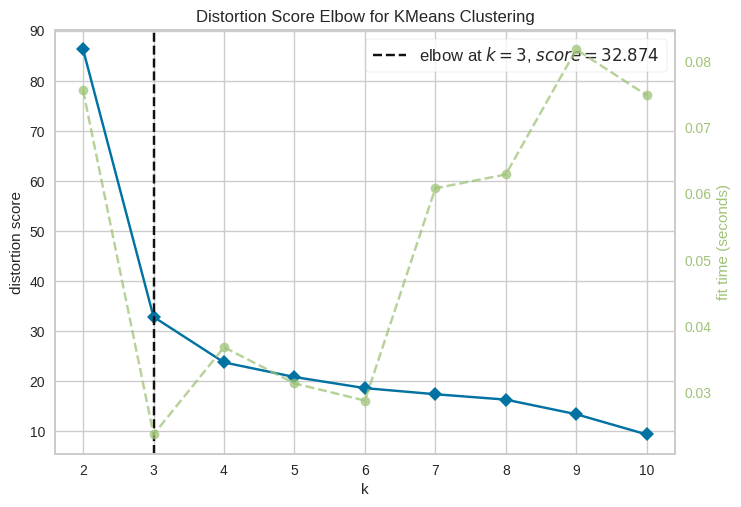

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [15]:
# importer KELbowVisualizer
from yellowbrick.cluster import KElbowVisualizer
# Instantier le modèle kmeans
kmeans_model = KMeans(init = 'random', max_iter=500)
# Instantier KELbowVisualizer
Elbow_M = KElbowVisualizer(kmeans_model, k=10)
# Entrainement
Elbow_M.fit(x)
# Visualiser l'elbow
Elbow_M.show()

In [16]:
# instantier le modèle
kmeans_model = KMeans(n_clusters = 3, init= 'random', max_iter = 500)
# Entrainer le modèle
kmeans_model.fit(x)

KMeans(init='random', max_iter=500, n_clusters=3)

#### <font color='teal'> Prédiction

In [17]:
# Prediction de la partition des données
Pred = kmeans_model.predict(x)
# Afficher la partition
Pred[:300]

array([2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       1, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 0, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], d

In [18]:
# Nombre d'observations dans chaque classe
val = pd.Series(Pred).value_counts()
val

,count
2,2697
0,298
1,155


In [19]:
# Function de visualisation du diagramme en barre des nombres d'observations.
def bar_plot(val):
  fig = px.bar(x = val.index.astype(str), y = val.values, color = val.index.astype(str), text_auto = True)
  fig.show()

In [20]:
# Barplot des nombres d'observations
bar_plot(val)

In [21]:
# Function de visualisuation des classes
def scatter_plot(New_df,Pred):
  fig = px.scatter(New_df, x='PCA1', y='PCA2', color=Pred.astype(str))
  fig.show()

In [22]:
# Visualiser les classes
scatter_plot(New_df,Pred)

##### <font color='teal'> Indice de silhouette de la partition du Kmeans

In [23]:
# Silhouette score
from sklearn.metrics import silhouette_score
#
sil_KMeans = silhouette_score(x, Pred)
print(f"La silhouette KMeans : {sil_KMeans: .3f}")

La silhouette KMeans :  0.785


### <font color='gold'> CAH

In [24]:
# Importer linkage et dendrogram
from scipy.cluster.hierarchy import  linkage, dendrogram

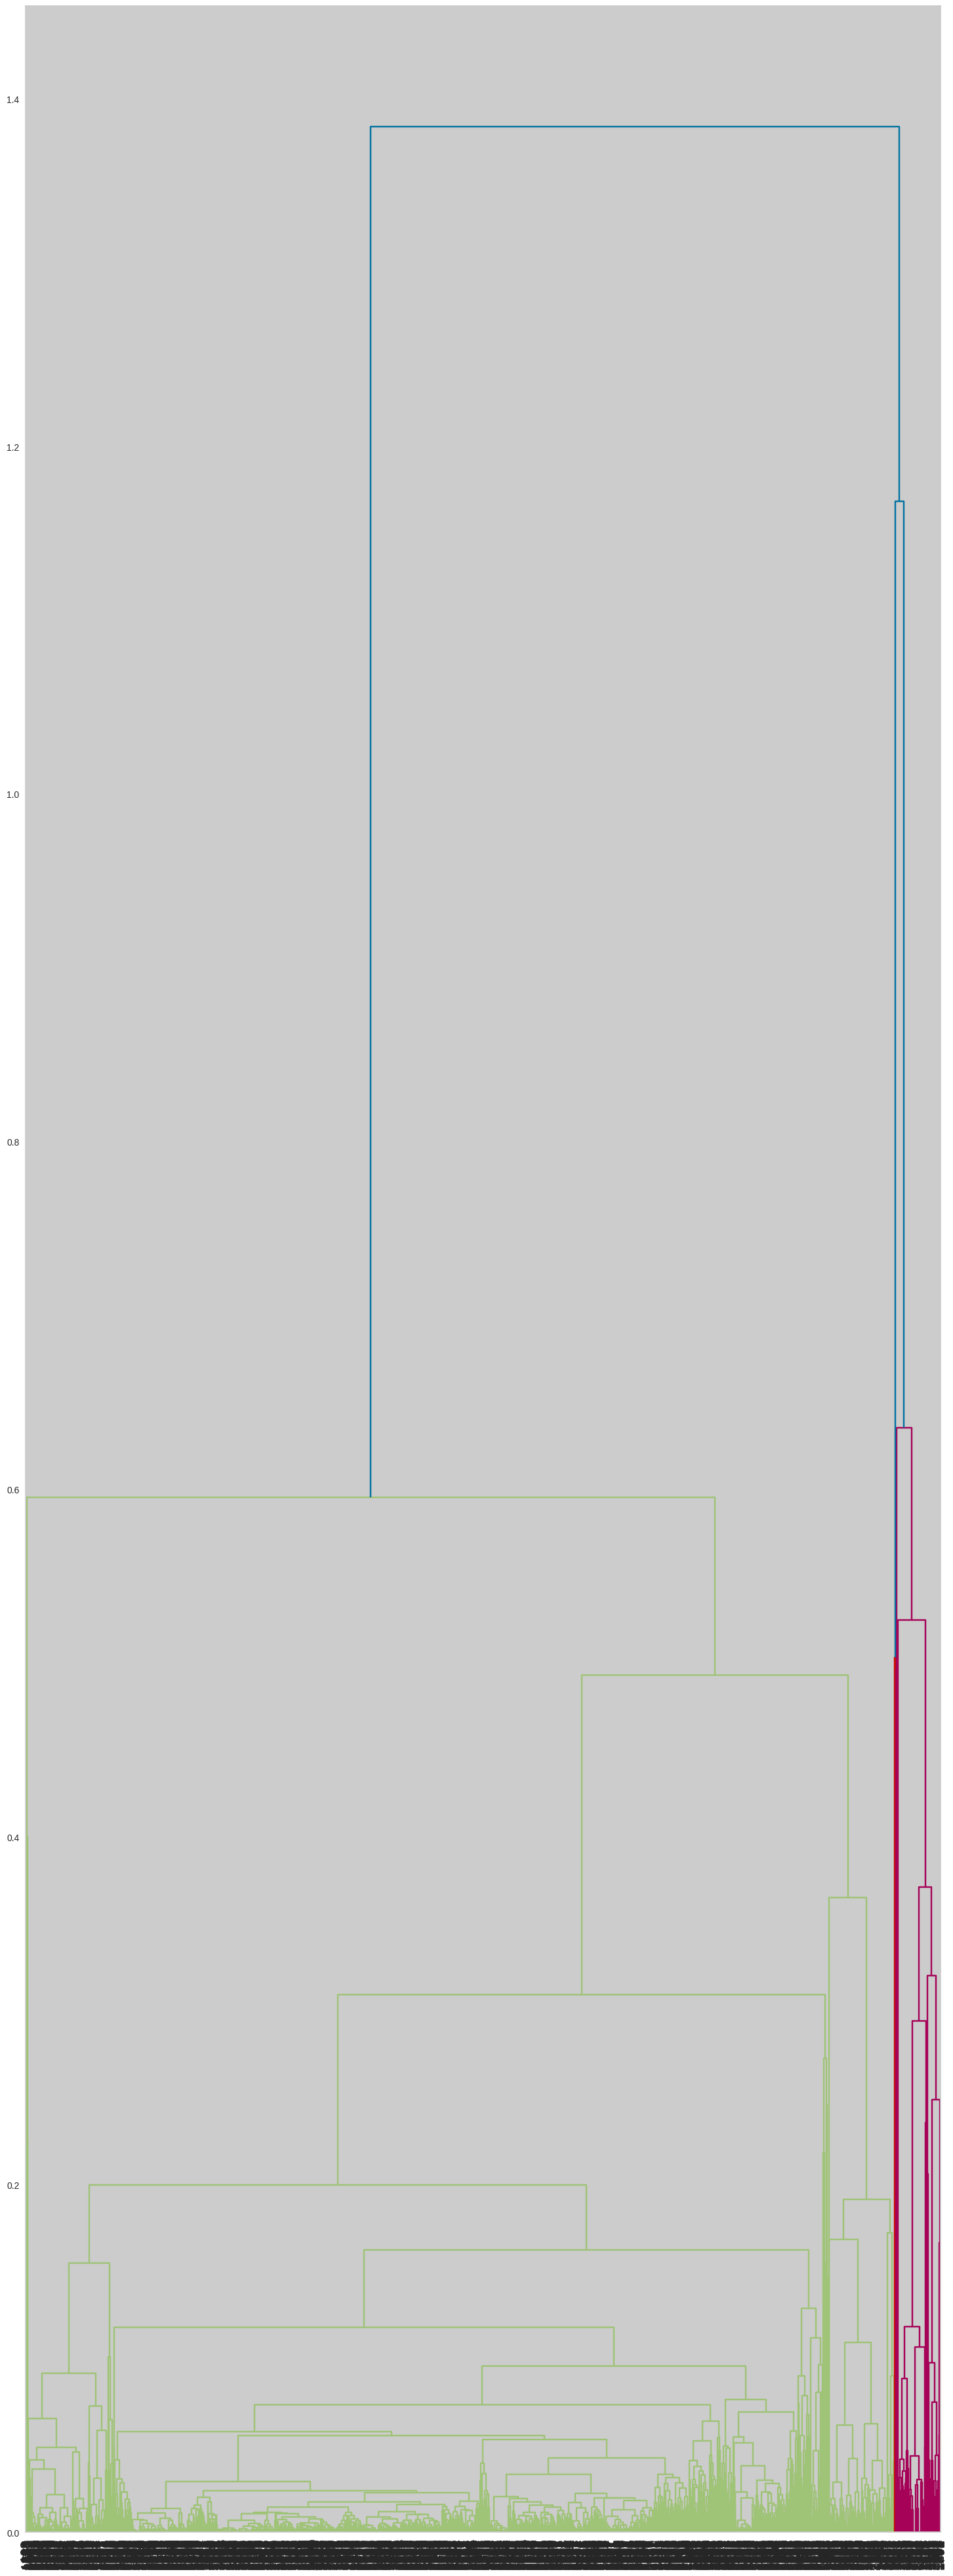

In [25]:
# Visualiser le dendrograme
import matplotlib.pyplot as plt
Z = linkage(x, 'average')# matrice des liaisons
plt.figure(figsize=(18, 50))
dendro = dendrogram(Z, leaf_font_size=15, orientation = 'top')

In [26]:
from sklearn.cluster import AgglomerativeClustering
# Initier AgglomerativeClustering
cah_model = AgglomerativeClustering(n_clusters = 2, linkage = 'average')
# Entrainer le modèle
cah_model.fit(x)

AgglomerativeClustering(linkage='average')

In [29]:
# Prédire la partition des données
pred = cah_model.fit_predict(x)
# Afficher la partition
pred[:200]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [30]:
# Nombre d'observations dans chaque classe
val1  = pd.Series(pred).value_counts()
val1

,count
1,2992
0,158


In [31]:
# Diagramme en barre des nombres d'observations
bar_plot(val1)

In [32]:
# Visualiser les classes
scatter_plot(New_df,pred)

In [33]:
# Silhouette score
sil_cah = silhouette_score(x,pred)
print(f'La silhouette CAH: {sil_cah: .3f}')

La silhouette CAH:  0.885


### <font color='gold'> DBSCAN

In [34]:
# Importer le modèle DBSCAN
from sklearn.cluster import DBSCAN

##### <font color='teal'> Recherche des paramètres optimaux

In [ ]:
# # Recherche des paramètres optimaux
# from utils import eps_min_sam_opt
# # Faire appel à la fonction eps_min_sam_opt
# eps_min_sam_opt(x)

In [35]:
# Instantier le modèle avec  eps = 0.2 et min_samples =9
dbscan_model = DBSCAN(eps= 0.2, min_samples = 9)
# Entrainer le modèle
dbscan_model.fit(x)

DBSCAN(eps=0.2, min_samples=9)

In [36]:
# Prédire la partition
Predi = dbscan_model.labels_
Predi[:300]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,
        0,  0,  0,  0,  0

In [37]:
# Nombre d'observations dans chaque classe
val2  = pd.Series(Predi).value_counts()
val2

,count
0,2985
1,144
-1,21


In [38]:
# Diagramme en barre des nombres d'observations
bar_plot(val2)

In [39]:
# Visualiser les classes
scatter_plot(New_df,Predi)

In [40]:
# les anomalies
anomalies = df.index[Predi == -1]
anomalies

Index(['Client69', 'Client169', 'Client242', 'Client442', 'Client819',
       'Client1102', 'Client1133', 'Client1192', 'Client1202', 'Client1319',
       'Client1400', 'Client1419', 'Client1429', 'Client1573', 'Client1602',
       'Client1619', 'Client1629', 'Client1702', 'Client1852', 'Client1883',
       'Client1989'],
      dtype='object')

In [41]:
# partition sans les anomalies (-1)
Pred_sans_anomalies = Predi[Predi!=-1]
# Dataframe sans les anomalies(-1)
df_sans_anamolies = df[Predi!=-1]
# New_df sans anomalies
New_df_sans_anomalies = New_df[Predi !=-1]
# la matrice
x_sans_anomalies = x[Predi !=-1]

In [42]:
# visualiser les classes sans les anomalies
scatter_plot(New_df_sans_anomalies, Pred_sans_anomalies)

In [43]:
# silhouette score de la partition finale
sil_dbscan = silhouette_score(x_sans_anomalies, Pred_sans_anomalies)
print(f"La silhouette de DBSCAN : {sil_dbscan:.3f}")

La silhouette de DBSCAN : 0.892


In [44]:
# Diagrammes en barre des silhouettes
Model_Names = ['KMEANS', 'CAH','DBSCAN']
sil = [sil_KMeans, sil_cah, sil_dbscan]
fig = px.bar(x= Model_Names, y = sil, color = Model_Names, text_auto = True)
fig.show()

In [45]:
# les indidivus
Cluster_Names = []
for k in range(2):
  Cluster_Names.append(df_sans_anamolies.index[Pred_sans_anomalies ==k])

In [46]:
# # Les individus de la classe 0
Cluster_Names[0]

Index(['Client1', 'Client2', 'Client3', 'Client4', 'Client5', 'Client6',
       'Client7', 'Client8', 'Client9', 'Client10',
       ...
       'Client3141', 'Client3142', 'Client3143', 'Client3144', 'Client3145',
       'Client3146', 'Client3147', 'Client3148', 'Client3149', 'Client3150'],
      dtype='object', length=2985)

In [47]:
# Les individus de la classe 1
Cluster_Names[1]

Index(['Client19', 'Client119', 'Client129', 'Client133', 'Client202',
       'Client219', 'Client229', 'Client232', 'Client233', 'Client302',
       ...
       'Client2052', 'Client2069', 'Client2079', 'Client2083', 'Client2819',
       'Client2869', 'Client3002', 'Client3019', 'Client3029', 'Client3033'],
      dtype='object', length=144)

---

### <font color='gold'> Déploiement du meilleur modèle (DBSCAN) avec Gradio

La comparaison des indices de silhouette montre que **DBSCAN** fournit la meilleure partition.
C'est donc ce modèle que nous allons déployer.

**Objectif du déploiement** : saisir les caractéristiques d'un **nouveau client** et obtenir
automatiquement la **classe** à laquelle il appartient (parmi les classes de la partition).

#### <font color='teal'> 1. Comprendre le problème : DBSCAN n'a pas de méthode `predict()`

Avec KMeans, on peut écrire `kmeans_model.predict(nouveau_client)` : chaque classe possède un centre,
il suffit de trouver le centre le plus proche.

DBSCAN, lui, **ne calcule pas de centres**. Il n'a donc pas de méthode `predict()` : il sait seulement
classer les points qu'il a vus pendant l'entraînement (`dbscan_model.labels_`).

**La solution, très simple** : DBSCAN mémorise les **points cœur** (les points denses autour desquels
les classes se sont formées). Ils sont stockés dans `dbscan_model.components_`.
Pour un nouveau client, on applique exactement la règle de DBSCAN :

1. on cherche le **point cœur le plus proche** du nouveau client ;
2. si la distance est **inférieure ou égale à `eps`** (ici 0.2), le client reçoit la **classe de ce point cœur** ;
3. sinon, le client est trop loin de toutes les zones denses : c'est une **anomalie** (classe `-1`).

In [48]:
# Installer Gradio
!pip install gradio

In [49]:
# Importer Gradio
import gradio as gr

#### <font color='teal'> 2. Récupérer les points cœur de DBSCAN

In [50]:
# Les points cœur mémorisés par DBSCAN
points_coeur = dbscan_model.components_
# La classe de chacun de ces points cœur
labels_coeur = dbscan_model.labels_[dbscan_model.core_sample_indices_]

print("Nombre de points cœur :", len(points_coeur))
print("Classes présentes      :", np.unique(labels_coeur))

Nombre de points cœur : 3119
Classes présentes      : [0 1]


#### <font color='teal'> 3. La fonction de prédiction

Attention : le modèle a été entraîné sur les données **normalisées** (`x = normalize(x)`).
Il faut donc appliquer **exactement le même prétraitement** au nouveau client.

Bonne nouvelle : `normalize()` traite chaque ligne indépendamment des autres (elle divise chaque ligne
par sa norme). On peut donc normaliser un client seul, sans avoir besoin des données d'entraînement.

In [51]:
def predire_classe(nouveau_client):

    #Mettre le client sous forme de matrice à 1 ligne, puis le normaliser
    client = np.array(nouveau_client, dtype=float).reshape(1, -1)
    client = normalize(client)

    #Distances entre le client et tous les points cœur
    distances = np.linalg.norm(points_coeur - client, axis=1)

    #Le point cœur le plus proche
    plus_proche = distances.argmin()

    #Règle de DBSCAN : dans le voisinage (eps) ou pas ?
    if distances[plus_proche] <= dbscan_model.eps:
        # classe du point cœur le plus proche
        return labels_coeur[plus_proche]
    else:
        # anomalie
        return -1

In [53]:
# Test rapide
print("Classe prédite  :", predire_classe(df.iloc[0].values))
print("Classe de DBSCAN:", Predi[0])

Classe prédite  : 0
Classe de DBSCAN: 0


#### <font color='teal'> 4. Interpréter les classes

Avant de livrer l'application, il faut savoir **ce que représente chaque classe**, pour afficher un
message compréhensible par l'utilisateur final. On regarde le profil moyen de chaque classe.

In [ ]:
# Profil moyen de chaque classe (sans les anomalies)
profil = df_sans_anamolies.groupby(Pred_sans_anomalies).mean().round(2)
profil

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Status,Age,Customer Value
0,8.05,0.08,32.54,0.99,4719.37,73.28,77.09,24.79,2.82,1.22,30.91,496.46
1,0.00,0.11,32.45,0.02,0.00,0.00,0.31,0.00,2.87,1.78,32.78,0.83


In [55]:
# Noms des classes
noms_classes = {
    0: "client fidèle",
    1: "client non fidèle",
}

#### <font color='teal'> 5. La fonction appelée par l'application

Gradio enverra les 12 caractéristiques saisies dans le formulaire. Le `*` devant `valeurs` permet de
récupérer toutes ces valeurs dans une seule liste, **dans l'ordre des colonnes de `df`**.

In [56]:
def affecter_client(*valeurs):
    classe = predire_classe(valeurs)
    if classe == -1:
        return "Client atypique (anomalie): il ne ressemble à aucune classe."
    nom = noms_classes[classe]
    return "C'est un  " + nom

#### <font color='teal'> 6. L'interface Gradio

On crée un champ numérique par variable. La liste `df.columns` garantit que les champs sont
**dans le même ordre** que les colonnes utilisées à l'entraînement.

In [57]:
# Un champ de saisie par variable, pré-rempli avec la valeur médiane
champs = [gr.Number(label=col, value=float(df[col].median())) for col in df.columns]

# Trois clients du jeu de données, pour tester l'application en un clic
exemples = df.head(3).values.tolist()
interface = gr.Interface(
    fn=affecter_client,
    inputs=champs,
    outputs=gr.Textbox(label="Résultat"),
    title="Segmentation des clients - modèle DBSCAN",
    description="Saisissez les caractéristiques d'un client pour connaître sa classe.",
    examples=exemples
)

In [58]:
# Lancer l'application
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://781585f7aa482ffb40.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---

#### <font color='teal'> 7. Mettre l'application en ligne (Github + Streamlit)


In [ ]:
# Sauvegarder tout ce dont l'application aura besoin
import joblib
artefacts = {
    "points_coeur": points_coeur,
    "labels_coeur": labels_coeur,
    "eps": dbscan_model.eps,
    "colonnes": list(df.columns),
    "valeurs_defaut": df.median().tolist(),
    "exemples": df.head(3).values.tolist(),
    "noms_classes": noms_classes,
}

joblib.dump(artefacts, "modele_dbscan.joblib")

Fichier modele_dbscan.joblib enregistré.
